In [10]:
# instalation des dependences
!pip install nibabel scikit-image tqdm -q
!pip install torchmetrics -q
print("Dependances installees")

Dependances installees


# Montage Google Drive & Chargement du Dataset Complet

In [11]:
# ─── CELLULE 1 : Installations et Configuration Kaggle ───
!pip install pytorch-lightning torchmetrics nibabel scikit-image tqdm kaggle -q

import os

# Configuration de votre token Kaggle
os.environ['KAGGLE_API_TOKEN'] = "KGAT_43f4d2ab6c202e5ab6a17e187596b3a1"
print("✅ Environnement prêt et Token Kaggle configuré !")

# ─── CELLULE 2 : Téléchargement des données ───
# REMPLACEZ 'dschettler8845/brats-2021-task1' par le bon ID si ce n'est pas celui-ci
!kaggle datasets download -d dschettler8845/brats-2021-task1
!mkdir -p ./data/BraTS2021_Training_Data
!unzip -o -q brats-2021-task1.zip -d ./data/BraTS2021_Training_Data
print("✅ Données téléchargées !")

✅ Environnement prêt et Token Kaggle configuré !
Dataset URL: https://www.kaggle.com/datasets/dschettler8845/brats-2021-task1
License(s): copyright-authors
100%|███████████████████████████████████████| 12.3G/12.3G [01:11<00:00, 184MB/s]

✅ Données téléchargées !


In [14]:
# 1. Téléchargement du dataset depuis Kaggle
!kaggle datasets download -d dschettler8845/brats-2021-task1

# 2. Création du dossier cible
!mkdir -p ./data/BraTS2021_Training_Data

# 3. Décompression silencieuse (-q) ET forçage de l'écrasement (-o)
!unzip -o -q brats-2021-task1.zip -d ./data/BraTS2021_Training_Data

# 4. (Optionnel) Supprimer le zip pour libérer de l'espace disque
!rm brats-2021-task1.zip

!echo "✅ Dataset téléchargé, extrait et prêt à être utilisé !"

Dataset URL: https://www.kaggle.com/datasets/dschettler8845/brats-2021-task1
License(s): copyright-authors
100%|███████████████████████████████████████| 12.3G/12.3G [01:44<00:00, 126MB/s]

✅ Dataset téléchargé, extrait et prêt à être utilisé !


In [25]:
import os
import tarfile
from tqdm.auto import tqdm

data_dir = './data/BraTS2021_Training_Data'
cache_file = './data/brats_slice_cache.json'

# 1. Nettoyage de l'ancien cache cassé
if os.path.exists(cache_file):
    os.remove(cache_file)
    print("🗑️ Ancien cache vide supprimé avec succès !")

# 2. Extraction sécurisée des fichiers .tar
tar_files = [f for f in os.listdir(data_dir) if f.endswith('.tar')]

if len(tar_files) > 0:
    print(f"📦 {len(tar_files)} archives .tar trouvées. Début de l'extraction...")
    for tar_name in tqdm(tar_files, desc="Extraction des patients"):
        tar_path = os.path.join(data_dir, tar_name)
        try:
            # Extraction
            with tarfile.open(tar_path, 'r') as tar:
                tar.extractall(path=data_dir)
            # Suppression du .tar pour libérer de l'espace
            os.remove(tar_path)
        except Exception as e:
            print(f"⚠️ Erreur lors de l'extraction de {tar_name}: {e}")
    print("✅ Extraction terminée ! Tous les .nii.gz sont prêts.")
else:
    print("ℹ️ Aucun fichier .tar à extraire. Ils sont peut-être déjà extraits.")

🗑️ Ancien cache vide supprimé avec succès !
ℹ️ Aucun fichier .tar à extraire. Ils sont peut-être déjà extraits.


In [26]:
# 1. On efface le dossier vide/corrompu pour repartir à zéro
!rm -rf ./data/BraTS2021_Training_Data
!mkdir -p ./data/BraTS2021_Training_Data

# 2. On re-télécharge le dataset
!echo "📥 Téléchargement depuis Kaggle..."
!kaggle datasets download -d dschettler8845/brats-2021-task1

# 3. On décompresse le ZIP (qui contient les fameux .tar)
!echo "📦 Décompression du ZIP..."
!unzip -o -q brats-2021-task1.zip -d ./data/BraTS2021_Training_Data

# 4. On vérifie que les fichiers sont bien là !
!echo "✅ Vérification (vous devriez voir des fichiers .tar ci-dessous) :"
!ls ./data/BraTS2021_Training_Data | head -n 5

📥 Téléchargement depuis Kaggle...
Dataset URL: https://www.kaggle.com/datasets/dschettler8845/brats-2021-task1
License(s): copyright-authors
100%|███████████████████████████████████████| 12.3G/12.3G [00:50<00:00, 260MB/s]

📦 Décompression du ZIP...
✅ Vérification (vous devriez voir des fichiers .tar ci-dessous) :
BraTS2021_00495.tar
BraTS2021_00621.tar
BraTS2021_Training_Data.tar


In [27]:
!echo "⏳ Extraction des archives .tar en cours (cela peut prendre quelques minutes)..."

# On se déplace dans le dossier, on extrait chaque .tar, puis on les supprime
!cd ./data/BraTS2021_Training_Data && for f in *.tar; do tar -xf "$f"; done
!cd ./data/BraTS2021_Training_Data && rm *.tar

!echo "✅ Extraction terminée ! Les vrais fichiers .nii.gz sont maintenant disponibles."

⏳ Extraction des archives .tar en cours (cela peut prendre quelques minutes)...
tar: <_io.TextIOWrapper name='./data/brats_slice_cache.json' mode='w' encoding='UTF-8'>: Cannot open: No such file or directory
tar: Error is not recoverable: exiting now
tar: <_io.TextIOWrapper name='./data/brats_slice_cache.json' mode='w' encoding='UTF-8'>: Cannot open: No such file or directory
tar: Error is not recoverable: exiting now
tar: <_io.TextIOWrapper name='./data/brats_slice_cache.json' mode='w' encoding='UTF-8'>: Cannot open: No such file or directory
tar: Error is not recoverable: exiting now
✅ Extraction terminée ! Les vrais fichiers .nii.gz sont maintenant disponibles.


In [31]:
# 1. On efface le dossier corrompu pour repartir à zéro
!rm -rf ./data
!mkdir -p ./data

# 2. Téléchargement et décompression propre
!echo "📥 Téléchargement Kaggle..."
!kaggle datasets download -d dschettler8845/brats-2021-task1
!echo "📦 Décompression du ZIP de base..."
!unzip -o -q brats-2021-task1.zip -d ./data/BraTS2021_Training_Data
!rm brats-2021-task1.zip
!echo "✅ Fichiers prêts pour l'extraction Python !"

📥 Téléchargement Kaggle...
Dataset URL: https://www.kaggle.com/datasets/dschettler8845/brats-2021-task1
License(s): copyright-authors
100%|███████████████████████████████████████| 12.3G/12.3G [01:25<00:00, 155MB/s]

📦 Décompression du ZIP de base...
✅ Fichiers prêts pour l'extraction Python !


In [32]:
import os
import tarfile
import json
import nibabel as nib
import numpy as np
from tqdm.auto import tqdm
import warnings

# On masque les avertissements futurs pour garder un affichage propre
warnings.filterwarnings("ignore", category=DeprecationWarning)

BASE_DIR = './data/BraTS2021_Training_Data'
CACHE_FILE = './data/brats_slice_cache.json'
empty_thr = 0.05

# ─── 1. EXTRACTION SÉCURISÉE DES .TAR ───
tar_files = []
for root, dirs, files in os.walk(BASE_DIR):
    for f in files:
        if f.endswith('.tar'):
            tar_files.append(os.path.join(root, f))

if len(tar_files) > 0:
    print(f"📦 {len(tar_files)} fichiers .tar trouvés. Début de l'extraction (cela peut prendre quelques minutes)...")
    for tar_path in tqdm(tar_files, desc="Extraction des archives"):
        try:
            with tarfile.open(tar_path, 'r') as tar:
                # Ajout de filter='data' pour corriger l'avertissement rouge !
                tar.extractall(path=os.path.dirname(tar_path), filter='data')
            os.remove(tar_path) # On supprime proprement après extraction
        except Exception as e:
            print(f"⚠️ Erreur sur {tar_path}: {e}")
else:
    print("ℹ️ Aucun fichier .tar trouvé. (Peut-être déjà extraits ?)")

# ─── 2. RECHERCHE DES NIfTI ───
nii_files = []
for root, dirs, files in os.walk(BASE_DIR):
    for f in files:
        if f.endswith('.nii') or f.endswith('.nii.gz'):
            nii_files.append(os.path.join(root, f))

print(f"\n📊 Bilan : {len(nii_files)} fichiers NIfTI (.nii.gz) trouvés prêts à l'emploi.")

# ─── 3. CRÉATION DU CACHE JSON ───
if len(nii_files) > 0:
    print("\n🧠 Création du cache JSON (Analyse des volumes)...")
    slices_list = []
    for path in tqdm(nii_files, desc="Analyse des volumes NIfTI"):
        try:
            vol = nib.load(path).get_fdata().astype(np.float32)
            for z in range(vol.shape[2]):
                s = vol[:, :, z]
                if np.count_nonzero(s) / s.size >= empty_thr:
                    slices_list.append((path, z))
        except Exception as e:
            print(f"⚠️ Impossible de lire {path}: {e}")

    with open(CACHE_FILE, 'w') as f:
        json.dump(slices_list, f)
    print(f"\n🎉 SUCCÈS ! Cache sauvegardé avec {len(slices_list)} coupes dans {CACHE_FILE}.")
else:
    print("\n❌ ERREUR : Aucun fichier NIfTI n'a été trouvé après l'extraction.")

📦 3 fichiers .tar trouvés. Début de l'extraction (cela peut prendre quelques minutes)...


Extraction des archives:   0%|          | 0/3 [00:00<?, ?it/s]


📊 Bilan : 6265 fichiers NIfTI (.nii.gz) trouvés prêts à l'emploi.

🧠 Création du cache JSON (Analyse des volumes)...


Analyse des volumes NIfTI:   0%|          | 0/6265 [00:00<?, ?it/s]


🎉 SUCCÈS ! Cache sauvegardé avec 625052 coupes dans ./data/brats_slice_cache.json.


# Imports

In [34]:
import os, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from skimage.metrics import structural_similarity as ssim
from sklearn.decomposition import PCA
from tqdm.notebook import tqdm



In [35]:
# ── Seed pour la reproductibilite ─────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if device.type == 'cuda':
    print(f"   GPU : {torch.cuda.get_device_name(0)}")

Device : cuda
   GPU : Tesla T4


In [37]:
import os
data_root = './data/BraTS2021_Training_Data'

if os.path.exists(data_root):
    items = os.listdir(data_root)
    print(f"✅ Dossier trouvé ! Il contient {len(items)} éléments. Voici les 10 premiers :\n")
    
    # On affiche seulement les 10 premiers pour ne pas inonder l'écran
    for item in items[:10]:
        print(f" - '{item}'")
        
    if len(items) > 10:
        print(" ... (etc)")
else:
    print("❌ Dossier introuvable. Les données Kaggle ne sont pas encore extraites.")

✅ Dossier trouvé ! Il contient 1262 éléments. Voici les 10 premiers :

 - 'BraTS2021_00674'
 - 'BraTS2021_01179'
 - 'BraTS2021_01649'
 - 'BraTS2021_00410'
 - 'BraTS2021_00601'
 - 'BraTS2021_00387'
 - 'BraTS2021_00389'
 - 'BraTS2021_01335'
 - 'BraTS2021_01526'
 - 'BraTS2021_00417'
 ... (etc)


In [6]:
# print(f"Contenu de '{CACHE_FILE.rsplit('/', 1)[0]}':\n")
# for item in os.listdir(CACHE_FILE.rsplit('/', 1)[0]):
#     print(f" - '{item}'")

# Dataset BraTS (toutes modalités, toutes coupes)


In [38]:
import os
import json
import nibabel as nib
import numpy as np
from tqdm.auto import tqdm # <-- Modifié pour plus de stabilité

# ─── NOUVEAUX CHEMINS LOCAUX (Lightning/Kaggle) ───
DATA_DIR = './data/BraTS2021_Training_Data'
CACHE_FILE = './data/brats_slice_cache.json'
empty_thr = 0.05

print("Étape 1 : Création du cache... Cela va prendre du temps.")
slices_list = []

# Trouver tous les fichiers NIfTI
nii_files = []
for root, dirs, files in os.walk(DATA_DIR):
    for fname in files:
        if fname.endswith('.nii') or fname.endswith('.nii.gz'):
            nii_files.append(os.path.join(root, fname))

print(f"{len(nii_files)} volumes 3D trouvés. Analyse en cours...")

# Sécurité : on s'assure que le dossier 'data' existe bien avant de sauvegarder
os.makedirs(os.path.dirname(CACHE_FILE), exist_ok=True)

# Analyser les coupes pour exclure celles qui sont vides
for path in tqdm(nii_files, desc="Analyse des volumes"):
    try:
        vol = nib.load(path).get_fdata().astype(np.float32)
        n_z = vol.shape[2]
        for z in range(n_z):
            s = vol[:, :, z]
            # On ne garde que les coupes qui ont suffisamment de données (non vides)
            if np.count_nonzero(s) / s.size >= empty_thr:
                slices_list.append((path, z))
    except Exception as e:
        print(f"⚠️ Erreur de lecture sur {os.path.basename(path)}: {e}")

# Sauvegarder la liste dans le fichier JSON
with open(CACHE_FILE, 'w') as f:
    json.dump(slices_list, f)

print(f"\n✅ Cache généré avec succès ! {len(slices_list)} coupes sauvegardées dans {CACHE_FILE}")

Étape 1 : Création du cache... Cela va prendre du temps.
6265 volumes 3D trouvés. Analyse en cours...


Analyse des volumes:   0%|          | 0/6265 [00:00<?, ?it/s]


✅ Cache généré avec succès ! 625052 coupes sauvegardées dans ./data/brats_slice_cache.json


In [39]:
import os
import json
import torch
import nibabel as nib
from tqdm.auto import tqdm  # <-- Modifié pour la compatibilité Lightning
import torch.nn.functional as F
from collections import defaultdict

# ─── NOUVEAUX CHEMINS LOCAUX ───
LOCAL_DATA_DIR = './data/brats_2d_slices'
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

CACHE_FILE = './data/brats_slice_cache.json'

print("Chargement du cache...")
with open(CACHE_FILE, 'r') as f:
    slices_list = json.load(f)
print(f"✅ {len(slices_list)} coupes trouvées dans le cache.")

# ─── L'ASTUCE D'OPTIMISATION : Regrouper par volume ──────────────────
# Au lieu d'ouvrir le fichier pour chaque coupe, on groupe les coupes
# par fichier pour n'ouvrir chaque fichier qu'UNE SEULE FOIS.
volumes_dict = defaultdict(list)
for idx, (path, z) in enumerate(slices_list):
    volumes_dict[path].append((idx, z))

print(f"🔄 Optimisation : regroupé en {len(volumes_dict)} volumes uniques.")

# ─── Extraction rapide ───────────────────────────────────────────────
# On boucle sur les volumes uniques
for path, slices_in_vol in tqdm(volumes_dict.items(), desc="Extraction (par volume)"):
    try:
        # ON CHARGE LE VOLUME COMPLET UNE SEULE FOIS !
        vol = nib.load(path).get_fdata().astype(np.float32)

        # On extrait toutes les coupes de ce volume
        for idx, z in slices_in_vol:
            s = vol[:, :, z]

            # Normalize
            s_min, s_max = s.min(), s.max()
            if s_max > s_min:
                s = (s - s_min) / (s_max - s_min)

            # Resize and convert to tensor
            t = torch.tensor(s).unsqueeze(0)
            t = F.interpolate(t.unsqueeze(0), size=(128, 128), mode='bilinear', align_corners=False).squeeze(0)

            # Save as an individual tensor file
            torch.save(t, f"{LOCAL_DATA_DIR}/slice_{idx}.pt")

    except Exception as e:
        print(f"⚠️ Erreur sur le volume {os.path.basename(path)}: {e}")

print("\n✅ Extraction terminée ! Vos tenseurs sont prêts.")

Chargement du cache...
✅ 625052 coupes trouvées dans le cache.
🔄 Optimisation : regroupé en 5467 volumes uniques.


Extraction (par volume):   0%|          | 0/5467 [00:00<?, ?it/s]


✅ Extraction terminée ! Vos tenseurs sont prêts.


In [40]:
import os
import torch
import pytorch_lightning as pl
from torch.utils.data import Dataset, DataLoader, random_split

# ─── 1. Le Dataset (Lecture rapide des fichiers locaux) ───
class BraTSDatasetFast(Dataset):
    def __init__(self, data_dir='./data/brats_2d_slices'): # <-- Nouveau chemin !
        self.data_dir = data_dir
        self.files = [f for f in os.listdir(data_dir) if f.endswith('.pt')]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_dir, self.files[idx])
        t = torch.load(file_path, weights_only=True)
        return t, t

# ─── 2. Le DataModule (Standard PyTorch Lightning) ───
class BraTSDataModule(pl.LightningDataModule):
    def __init__(self, data_dir='./data/brats_2d_slices', batch_size=32, seed=42):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.seed = seed

    def setup(self, stage=None):
        # Cette fonction s'exécute automatiquement avant l'entraînement
        full_dataset = BraTSDatasetFast(data_dir=self.data_dir)
        n_total = len(full_dataset)

        if n_total == 0:
            raise ValueError(f"Aucun fichier .pt trouvé dans {self.data_dir}. L'extraction a-t-elle bien fonctionné ?")

        n_val   = max(1, int(0.20 * n_total))
        n_train = n_total - n_val

        self.train_set, self.val_set = random_split(
            full_dataset, 
            [n_train, n_val],
            generator=torch.Generator().manual_seed(self.seed)
        )
        print(f"\n📊 Dataset DataModule prêt :")
        print(f"   Total  : {n_total} coupes")
        print(f"   Train  : {n_train} ({n_train/n_total*100:.1f}%)")
        print(f"   Val    : {n_val}   ({n_val/n_total*100:.1f}%)")

    def train_dataloader(self):
        # Astuce : On monte num_workers à 4 sur Lightning Studios pour accélérer le chargement
        return DataLoader(self.train_set, batch_size=self.batch_size, shuffle=True, 
                          num_workers=4, pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val_set, batch_size=self.batch_size, shuffle=False, 
                          num_workers=4, pin_memory=True)

# Architecture de l'Auto-encodeur

In [41]:
import pytorch_lightning as pl
import torch.nn as nn
import torch.optim as optim
from torchmetrics.image import StructuralSimilarityIndexMeasure

class BraTSAutoencoderLightning(pl.LightningModule):
    def __init__(self, latent_dim=256, lr=1e-3):
        super().__init__()
        # Sauvegarde automatiquement les arguments (comme lr et latent_dim) pour les checkpoints
        self.save_hyperparameters() 

        # ── EXACTEMENT VOTRE ENCODEUR ──────────────────────────────────
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
        )
        self.flatten = nn.Flatten()
        self.embedding_layer = nn.Linear(64 * 16 * 16, latent_dim)

        # ── EXACTEMENT VOTRE DÉCODEUR ──────────────────────────────────
        self.unflatten = nn.Linear(latent_dim, 64 * 16 * 16)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.ConvTranspose2d(16,  1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

        # ── AJOUT LIGHTNING : Définition des Loss et Métriques ─────────
        self.criterion = nn.MSELoss()
        self.ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0)

    # ── EXACTEMENT VOTRE FORWARD ───────────────────────────────────────
    def forward(self, x):
        enc      = self.encoder(x)
        flat     = self.flatten(enc)
        emb      = self.embedding_layer(flat)
        unflat   = self.unflatten(emb).view(-1, 64, 16, 16)
        recon    = self.decoder(unflat)
        return recon, emb

    # ── LA MAGIE LIGHTNING : Les étapes d'entraînement intégrées ───────
    def training_step(self, batch, batch_idx):
        imgs, targets = batch
        recon, _ = self(imgs) # Appelle la fonction forward automatiquement
        
        loss = self.criterion(recon, targets)
        ssim_val = self.ssim_metric(recon, targets)

        # Log automatique pour la barre de progression
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        self.log('train_ssim', ssim_val, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        imgs, targets = batch
        recon, _ = self(imgs)
        
        loss = self.criterion(recon, targets)
        ssim_val = self.ssim_metric(recon, targets)

        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_ssim', ssim_val, on_epoch=True, prog_bar=True)
        return loss

    def configure_optimizers(self):
        # On définit l'optimiseur et le scheduler directement dans le modèle
        optimizer = optim.Adam(self.parameters(), lr=self.hparams.lr)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
            },
        }

# Instanciation simple (Plus de .to(device) !)
model = BraTSAutoencoderLightning(latent_dim=256, lr=1e-3)
print("✅ Modèle Lightning prêt !")

✅ Modèle Lightning prêt !


# Fonction de calcul du SSIM batch

In [42]:
# ── Calcul SSIM en batch (sur GPU via torchmetrics) ──────────────────────
# from torchmetrics.image import StructuralSimilarityIndexMeasure

# # Initialize the metric once and move it to the GPU
# # data_range=1.0 because your images are normalized between 0 and 1
# ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

# print("Métrique SSIM (GPU) définie")

# train depuis zero

In [44]:
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor, TQDMProgressBar

# ─── 1. Préparation ──────────────────────────────────────────────────────────
pl.seed_everything(42)

# Instanciation de vos classes Lightning (créées dans les cellules précédentes)
datamodule = BraTSDataModule(batch_size=32)
model = BraTSAutoencoderLightning(latent_dim=256, lr=1e-3)

# ─── 2. Callbacks ────────────────────────────────────────────────────────────
checkpoint_callback = ModelCheckpoint(
    dirpath='./checkpoints/',
    filename='brats-autoencoder-best-{epoch:02d}-{val_loss:.4f}',
    monitor='val_loss',
    mode='min',
    save_top_k=1
)
lr_monitor = LearningRateMonitor(logging_interval='epoch')

# ✅ CORRECTION 1 : Ralentir le rafraîchissement de la barre pour éviter l'erreur rouge IOPub
progress_bar = TQDMProgressBar(refresh_rate=50)

# ─── 3. Le Trainer ───────────────────────────────────────────────────────────
trainer = pl.Trainer(
    max_epochs=50,
    accelerator="auto",
    devices=1,
    precision="16-mixed",
    gradient_clip_val=1.0,   # ✅ CORRECTION 2 : Bloque l'explosion des gradients (anti-NaN)
    callbacks=[checkpoint_callback, lr_monitor, progress_bar], # On ajoute progress_bar ici !
    log_every_n_steps=10
)

# ─── 4. Lancement de l'entraînement ────────────────────────────────────────
print("=" * 55)
print("🚀 DÉMARRAGE DU TRAINING PYTORCH LIGHTNING")
print("=" * 55)

trainer.fit(model, datamodule=datamodule)

print("=" * 55)
print(f"✅ Entraînement terminé !")
print(f"💾 Le meilleur modèle a été sauvegardé ici : {checkpoint_callback.best_model_path}")

Seed set to 42
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


🚀 DÉMARRAGE DU TRAINING PYTORCH LIGHTNING


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /teamspace/studios/this_studio/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



📊 Dataset DataModule prêt :
   Total  : 625052 coupes
   Train  : 500042 (80.0%)
   Val    : 125010   (20.0%)


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type                             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder         │ Sequential                       │ 23.5 K │ train │     0 │
│ 1 │ flatten         │ Flatten                          │      0 │ train │     0 │
│ 2 │ embedding_layer │ Linear                           │  4.2 M │ train │     0 │
│ 3 │ unflatten       │ Linear                           │  4.2 M │ train │     0 │
│ 4 │ decoder         │ Sequential                       │ 23.3 K │ train │     0 │
│ 5 │ criterion       │ MSELoss                          │      0 │ train │     0 │
│ 6 │ ssim_metric     │ StructuralSimilarityIndexMeasure │      0 │ train │     0 │
└───┴─────────────────┴──────────────────────────────────┴────────┴───────┴───────┘

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


✅ Entraînement terminé !
💾 Le meilleur modèle a été sauvegardé ici : /teamspace/studios/this_studio/checkpoints/brats-autoencoder-best-epoch=15-val_loss=0.0009-v1.ckpt


In [45]:
!ls -lh ./checkpoints/


total 194M
-rw-r--r-- 1 zouhairchoufa4 zouhairchoufa4 97M May  2 20:19 'brats-autoencoder-best-epoch=15-val_loss=0.0009-v1.ckpt'
-rw-r--r-- 1 zouhairchoufa4 zouhairchoufa4 97M May  2 17:57 'brats-autoencoder-best-epoch=15-val_loss=0.0009.ckpt'


⏳ Chargement du modèle...

📊 Dataset DataModule prêt :
   Total  : 625052 coupes
   Train  : 500042 (80.0%)
   Val    : 125010   (20.0%)
✅ Modèle chargé ! Affichage de 5 exemples :


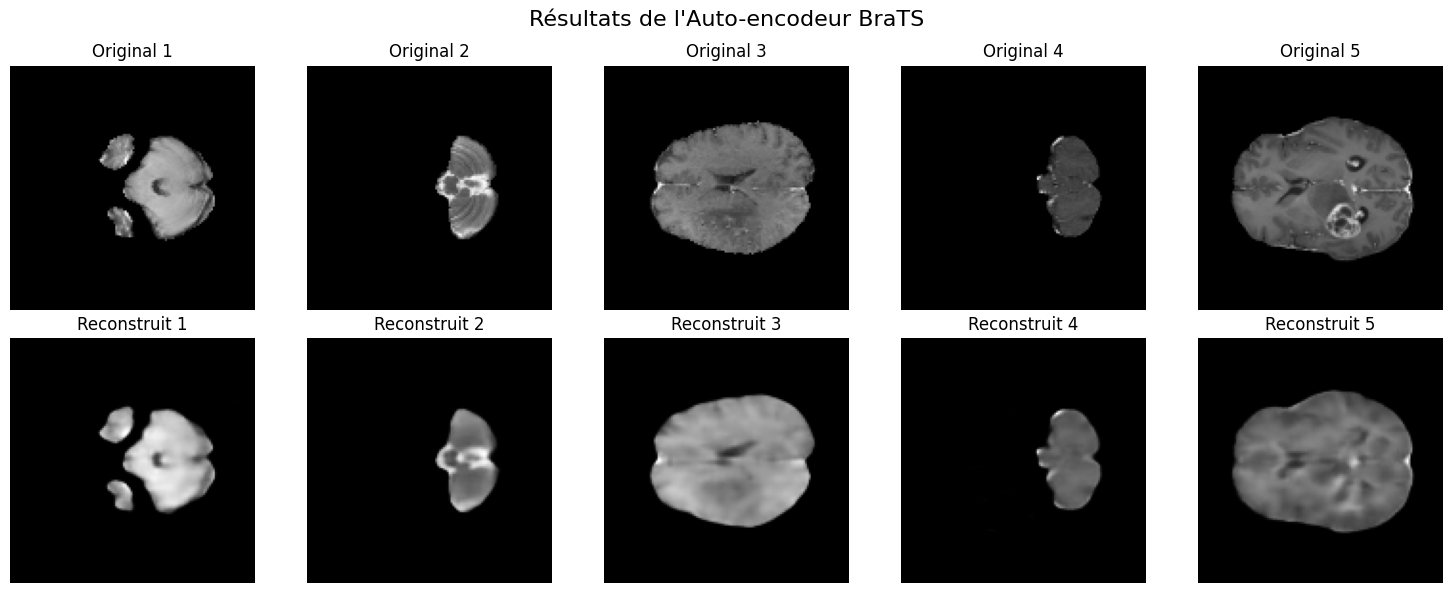

In [47]:
import torch
import matplotlib.pyplot as plt

# ─── 1. Chemin exact de votre modèle (vérifié via la commande ls) ───
ckpt_path = "./checkpoints/brats-autoencoder-best-epoch=15-val_loss=0.0009-v1.ckpt"

# ─── 2. Chargement du modèle depuis le checkpoint ───
print("⏳ Chargement du modèle...")
model = BraTSAutoencoderLightning.load_from_checkpoint(ckpt_path)
model.eval() # Mode évaluation (désactive les comportements d'entraînement)
model.to("cuda" if torch.cuda.is_available() else "cpu") # On s'assure qu'il est sur le bon processeur

# ─── 3. Récupération d'un batch d'images de validation ───
datamodule.setup() 
val_loader = datamodule.val_dataloader()
imgs, _ = next(iter(val_loader)) 
imgs = imgs.to(model.device)

# ─── 4. Reconstruction via l'Auto-encodeur ───
with torch.no_grad():
    recon, embeddings = model(imgs)

# ─── 5. Visualisation (Original vs Reconstruit) ───
print("✅ Modèle chargé ! Affichage de 5 exemples :")
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Résultats de l'Auto-encodeur BraTS", fontsize=16)

for i in range(5):
    # Ligne du haut : Images Originales
    axes[0, i].imshow(imgs[i].squeeze().cpu().numpy(), cmap='gray')
    axes[0, i].set_title(f"Original {i+1}")
    axes[0, i].axis('off')
    
    # Ligne du bas : Images Reconstruites par votre modèle
    axes[1, i].imshow(recon[i].squeeze().cpu().numpy(), cmap='gray')
    axes[1, i].set_title(f"Reconstruit {i+1}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [48]:
!cp ./checkpoints/brats-autoencoder-best-epoch=15-val_loss=0.0009-v1.ckpt ./my_brats_model.ckpt

In [49]:
import torch

# 1. On charge le super-fichier Lightning
model = BraTSAutoencoderLightning.load_from_checkpoint("./my_brats_model.ckpt")

# 2. On extrait UNIQUEMENT les poids du modèle (le dictionnaire classique)
poids_purs = model.state_dict()

# 3. On sauvegarde au format .pth standard de PyTorch
torch.save(poids_purs, "autoencoder_brats_poids_seuls.pth")

print("Fichier .pth généré avec succès !")

Fichier .pth généré avec succès !
